<a href="https://colab.research.google.com/github/gyuhyeongkim412-creator/financial-data-bootcamp/blob/main/Project_3_Deep_Learning_CF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# Project 3. Deep Learning CF - 딥러닝 기반 추천 (Exercise)

> Keras를 사용해 3가지 딥러닝 추천 모델을 단계적으로 구현합니다.
> 1) Embedding MF (행렬 분해를 Embedding으로)
> 2) Deep MF (Embedding + MLP)
> 3) AutoRec (오토인코더 기반)
> `___` 부분을 채워 넣으세요.

---

## 0. 환경 설정 및 데이터

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import urllib.request, zipfile, os

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Dot, Add, Flatten, Dense,
    Concatenate, Dropout, Activation
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD, Adam

# MovieLens 100K 다운로드
if not os.path.exists('ml-100k'):
    url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
    urllib.request.urlretrieve(url, "ml-100k.zip")
    with zipfile.ZipFile("ml-100k.zip", "r") as z:
        z.extractall(".")

# 데이터 로드
df = pd.read_csv(
    'ml-100k/u.data', sep='\t',
    names=['userId', 'movieId', 'rating', 'timestamp']
)

# 0-based 인덱스로 변환
df['userId'] = df['userId'] - 1
unique_movies = df['movieId'].unique()
movie2idx = {mid: idx for idx, mid in enumerate(sorted(unique_movies))}
df['movie_idx'] = df['movieId'].map(movie2idx)

N = df['userId'].max() + 1   # 사용자 수
M = df['movie_idx'].max() + 1  # 영화 수
print(f"Users: {N}, Movies: {M}, Ratings: {len(df)}")

# Train/Test 분할
df = shuffle(df, random_state=42)
cutoff = int(0.8 * len(df))
df_train = df.iloc[:cutoff]
df_test = df.iloc[cutoff:]

K = 10  # 잠재 인자 수
mu = df_train.rating.mean()
print(f"Global mean rating: {mu:.4f}")
```

---

## 1. Model A: Embedding-based Matrix Factorization

> 전통적 MF를 Embedding 레이어로 구현합니다.
> pred = u . m + b_u + b_m + mu

### 1-1. 모델 구조

```python
# 입력 레이어 (사용자 ID, 영화 ID)
u_input = Input(shape=(1,), name='user_input')
m_input = Input(shape=(1,), name='movie_input')

# Q1. User Embedding: N명의 사용자를 K차원 벡터로 매핑
u_embedding = ___(N, ___, name='user_embedding')(u_input)  # (batch, 1, K)

# Q2. Movie Embedding: M개의 영화를 K차원 벡터로 매핑
m_embedding = ___(M, ___, name='movie_embedding')(m_input)  # (batch, 1, K)

# Q3. User/Movie Bias: 각각 1차원 Embedding
u_bias = Embedding(N, ___, name='user_bias')(u_input)   # (batch, 1, 1)
m_bias = Embedding(M, ___, name='movie_bias')(m_input)  # (batch, 1, 1)

# Q4. User와 Movie 임베딩의 내적 (행렬 분해의 핵심)
x = ___(axes=2)([u_embedding, m_embedding])  # (batch, 1, 1)

# Q5. 내적 결과에 bias를 더함
x = ___()([x, u_bias, m_bias])  # (batch, 1, 1)

# Q6. 3D -> 1D로 변환
x = ___()(x)  # (batch, 1)

model_mf = Model(inputs=[u_input, m_input], outputs=x)
model_mf.compile(
    loss='mse',
    optimizer=SGD(learning_rate=0.08, momentum=0.9),
    metrics=['mse']
)
model_mf.summary()
```

### 1-2. 학습

```python
# Q7. 학습 - 평점에서 전체 평균(mu)을 빼서 정규화
r_mf = model_mf.fit(
    x=[df_train.userId.values, df_train.movie_idx.values],
    y=df_train.rating.values - ___,
    epochs=15,
    batch_size=128,
    validation_data=(
        [df_test.userId.values, df_test.movie_idx.values],
        df_test.rating.values - ___
    )
)
```

### 1-3. 결과 시각화

```python
plt.figure(figsize=(10, 4))
plt.plot(r_mf.history['loss'], label='train loss')
plt.plot(r_mf.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Model A: Embedding MF')
plt.legend()
plt.grid(True)
plt.show()
```

---

## 2. Model B: Deep Matrix Factorization (Embedding + MLP)

> Embedding 벡터를 Concatenate한 뒤 MLP로 비선형 상호작용을 학습합니다.

### 2-1. 모델 구조

```python
u_input2 = Input(shape=(1,))
m_input2 = Input(shape=(1,))

u_emb2 = Embedding(N, K)(u_input2)
m_emb2 = Embedding(M, K)(m_input2)

# Q8. Embedding을 Flatten하여 (batch, K)로 만듦
u_emb2 = ___()(u_emb2)
m_emb2 = ___()(m_emb2)

# Q9. User와 Movie 임베딩을 연결 -> (batch, 2K)
x2 = ___()([u_emb2, m_emb2])

# Q10. MLP 레이어 (비선형 상호작용 학습)
x2 = Dense(___)(x2)       # 은닉층 뉴런 수 (예: 128)
x2 = Activation('___')(x2) # 활성화 함수 (relu)
x2 = Dense(___)(x2)        # 출력층 (1개 뉴런 = 예측 평점)

model_deep = Model(inputs=[u_input2, m_input2], outputs=x2)
model_deep.compile(
    loss='mse',
    optimizer=SGD(learning_rate=0.08, momentum=0.9),
    metrics=['mse']
)
model_deep.summary()
```

### 2-2. 학습

```python
r_deep = model_deep.fit(
    x=[df_train.userId.values, df_train.movie_idx.values],
    y=df_train.rating.values - mu,
    epochs=15,
    batch_size=128,
    validation_data=(
        [df_test.userId.values, df_test.movie_idx.values],
        df_test.rating.values - mu
    )
)

plt.figure(figsize=(10, 4))
plt.plot(r_deep.history['loss'], label='train loss')
plt.plot(r_deep.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Model B: Deep MF (Embedding + MLP)')
plt.legend()
plt.grid(True)
plt.show()
```

---

## 3. Model C: AutoRec (오토인코더 기반 추천)

> User-Item 행렬의 행(사용자 벡터)을 입력으로 받아
> 오토인코더로 재구성하여 빈 칸을 예측합니다.

### 3-1. User-Item Matrix 구성

```python
from scipy.sparse import lil_matrix

# Q11. 희소 행렬로 User-Item Matrix 구성
A_train = lil_matrix((N, M))
A_test = lil_matrix((N, M))

for row in df_train.itertuples():
    A_train[row.userId, row.movie_idx] = row.rating

for row in df_test.itertuples():
    A_test[row.userId, row.movie_idx] = row.rating

# Dense로 변환 (100K는 크기가 작으므로 가능)
A_train_dense = A_train.toarray()
A_test_dense = A_test.toarray()

# Q12. 마스크 행렬: 평점이 있는 위치는 1, 없는 위치는 0
mask_train = (A_train_dense > 0) * ___
mask_test = (A_test_dense > 0) * ___

# 전체 평균으로 센터링
mu_auto = A_train_dense.sum() / mask_train.sum()
print(f"AutoRec mu: {mu_auto:.4f}")

A_train_centered = A_train_dense - mu_auto * mask_train
A_test_centered = A_test_dense - mu_auto * mask_test
```

### 3-2. AutoRec 모델

```python
import tensorflow.keras.backend as K_backend

# Q13. 커스텀 손실 함수: 평점이 존재하는 위치만 MSE 계산
def custom_loss(y_true, y_pred):
    # 0이 아닌 위치 마스크
    mask = K_backend.cast(K_backend.___(y_true, 0), dtype='float32')
    diff = y_pred - y_true
    # Q14. 마스크를 적용하여 0인 위치의 오차를 무시
    sqdiff = diff * diff * ___
    sse = K_backend.sum(K_backend.sum(sqdiff))
    n = K_backend.sum(K_backend.sum(mask))
    return sse / n

# Q15. 오토인코더 구조: Input(M) -> Hidden -> Output(M)
i = Input(shape=(___, ))   # 영화 수 = M
x3 = Dropout(0.7)(i)
x3 = Dense(___, activation='tanh')(x3)  # 은닉층 (예: 128)
x3 = Dense(___, activation=None)(x3)    # 출력층 = M (재구성)

model_autorec = Model(i, x3)
model_autorec.compile(
    loss=custom_loss,
    optimizer=SGD(learning_rate=0.08, momentum=0.9),
    metrics=[custom_loss]
)
model_autorec.summary()
```

### 3-3. 학습

```python
# Q16. AutoRec 학습 - 입력과 출력이 동일한 User 벡터
r_auto = model_autorec.fit(
    x=___,           # 센터링된 훈련 User-Item 벡터
    y=___,           # 동일한 벡터 (재구성 목표)
    epochs=20,
    batch_size=128,
    validation_data=(___, ___)  # 훈련 입력 -> 테스트 출력
)
```

> **Note**: validation_data는 (train input, test target)입니다.
> 훈련된 사용자 벡터를 입력하고, 테스트 위치의 평점을 맞추는지 확인합니다.

### 3-4. 결과 시각화

```python
plt.figure(figsize=(10, 4))
plt.plot(r_auto.history['loss'], label='train loss')
plt.plot(r_auto.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Custom MSE')
plt.title('Model C: AutoRec')
plt.legend()
plt.grid(True)
plt.show()
```

---

## 4. 전체 모델 비교

```python
from math import sqrt

print("=" * 50)
print("Final Validation MSE Comparison")
print("=" * 50)
print(f"  Embedding MF:  {r_mf.history['val_loss'][-1]:.4f}")
print(f"  Deep MF:       {r_deep.history['val_loss'][-1]:.4f}")
print(f"  AutoRec:       {r_auto.history['val_loss'][-1]:.4f}")
print("=" * 50)
```

---

## 정답 확인

정답은 `P3_DeepLearning_CF_answer.md`를 참고하세요.

```



로컬 IDE 설치 , 환경설정 , 가상환경, 깃활용, 시각화 (스트림릿)바이브코딩

In [ ]:

## 0. 환경 설정 및 데이터

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import urllib.request, zipfile, os

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Dot, Add, Flatten, Dense,
    Concatenate, Dropout, Activation
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD, Adam

# MovieLens 100K 다운로드
if not os.path.exists('ml-100k'):
    url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
    urllib.request.urlretrieve(url, "ml-100k.zip")
    with zipfile.ZipFile("ml-100k.zip", "r") as z:
        z.extractall(".")

# 데이터 로드
df = pd.read_csv(
    'ml-100k/u.data', sep='\t',
    names=['userId', 'movieId', 'rating', 'timestamp']
)

# 0-based 인덱스로 변환
df['userId'] = df['userId'] - 1
unique_movies = df['movieId'].unique()
movie2idx = {mid: idx for idx, mid in enumerate(sorted(unique_movies))}
df['movie_idx'] = df['movieId'].map(movie2idx)

N = df['userId'].max() + 1   # 사용자 수
M = df['movie_idx'].max() + 1  # 영화 수
print(f"Users: {N}, Movies: {M}, Ratings: {len(df)}")

# Train/Test 분할
df = shuffle(df, random_state=42)
cutoff = int(0.8 * len(df))
df_train = df.iloc[:cutoff]
df_test = df.iloc[cutoff:]

K = 10  # 잠재 인자 수
mu = df_train.rating.mean()
print(f"Global mean rating: {mu:.4f}")

Users: 943, Movies: 1682, Ratings: 100000
Global mean rating: 3.5319


In [ ]:
# 입력 레이어 (사용자 ID, 영화 ID)
u_input = Input(shape=(1,), name='user_input')
m_input = Input(shape=(1,), name='movie_input')

# Q1. User Embedding: N명의 사용자를 K차원 벡터로 매핑
u_embedding = Embedding(N, K, name='user_embedding')(u_input)  # (batch, 1, K)

# Q2. Movie Embedding: M개의 영화를 K차원 벡터로 매핑
m_embedding = Embedding(M, K, name='movie_embedding')(m_input)  # (batch, 1, K)

# Q3. User/Movie Bias: 각각 1차원 Embedding
u_bias = Embedding(N, 1, name='user_bias')(u_input)   # (batch, 1, 1)
m_bias = Embedding(M, 1, name='movie_bias')(m_input)  # (batch, 1, 1)

# Q4. User와 Movie 임베딩의 내적 (행렬 분해의 핵심)
x = Dot(axes=2)([u_embedding, m_embedding])  # (batch, 1, 1)

# Q5. 내적 결과에 bias를 더함
x = Add()([x, u_bias, m_bias])  # (batch, 1, 1)

# Q6. 3D -> 1D로 변환
x = Flatten()(x)  # (batch, 1)

model_mf = Model(inputs=[u_input, m_input], outputs=x)
model_mf.compile(
    loss='mse',
    optimizer=SGD(learning_rate=0.08, momentum=0.9),
    metrics=['mse']
)
model_mf.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 10)     │      9,430 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 10)     │     16,820 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1, 1)      │          0 │ user_embedding[0… │
│                     │                   │            │ movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias           │ (None, 1, 1)      │        943 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_bias          │ (None, 1, 1)      │      1,682 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1)      │          0 │ dot[0][0],        │
│                     │                   │            │ user_bias[0][0],  │
│                     │                   │            │ movie_bias[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ add[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,875 (112.79 KB)

 Trainable params: 28,875 (112.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Q7. 학습 - 평점에서 전체 평균(mu)을 빼서 정규화
r_mf = model_mf.fit(
    x=[df_train.userId.values, df_train.movie_idx.values],
    y=df_train.rating.values - mu,
    epochs=15,
    batch_size=128,
    validation_data=(
        [df_test.userId.values, df_test.movie_idx.values],
        df_test.rating.values - mu
    )
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.0252 - mse: 1.0252 - val_loss: 0.9476 - val_mse: 0.9476
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9103 - mse: 0.9103 - val_loss: 0.9134 - val_mse: 0.9134
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8841 - mse: 0.8841 - val_loss: 0.9001 - val_mse: 0.9001
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8713 - mse: 0.8713 - val_loss: 0.8939 - val_mse: 0.8939
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8636 - mse: 0.8636 - val_loss: 0.8913 - val_mse: 0.8913
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8580 - mse: 0.8580 - val_loss: 0.8886 - val_mse: 0.8886
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8520 - mse: 0.8520 - val_loss: 0.8853 - val_mse: 0.8853
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8449 - mse: 0.8449 - val_loss: 0.8814 - val_mse: 0.8814
Epoch 9/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - lo

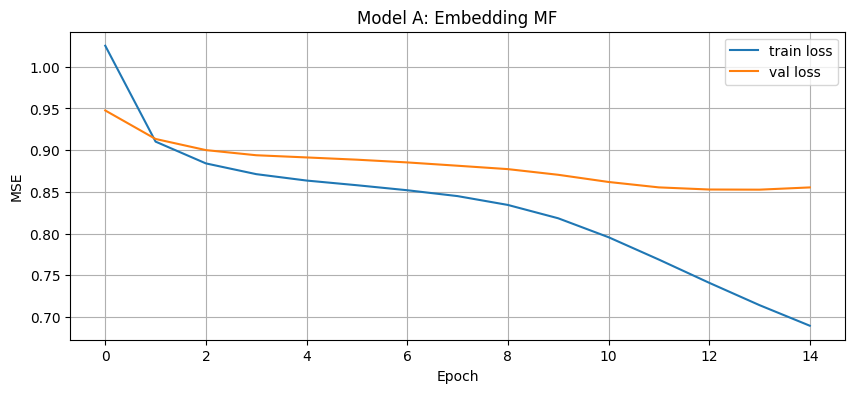

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(r_mf.history['loss'], label='train loss')
plt.plot(r_mf.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Model A: Embedding MF')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
u_input2 = Input(shape=(1,))
m_input2 = Input(shape=(1,))

u_emb2 = Embedding(N, K)(u_input2)
m_emb2 = Embedding(M, K)(m_input2)

# Q8. Embedding을 Flatten하여 (batch, K)로 만듦
u_emb2 = Flatten()(u_emb2)
m_emb2 = Flatten()(m_emb2)

# Q9. User와 Movie 임베딩을 연결 -> (batch, 2K)
x2 = Concatenate()([u_emb2, m_emb2])

# Q10. MLP 레이어 (비선형 상호작용 학습)
x2 = Dense(128)(x2)          # 은닉층 뉴런 수 128
x2 = Activation('relu')(x2)  # 활성화 함수 relu
x2 = Dense(1)(x2)            # 출력층 (1개 뉴런 = 예측 평점)

model_deep = Model(inputs=[u_input2, m_input2], outputs=x2)
model_deep.compile(
    loss='mse',
    optimizer=SGD(learning_rate=0.08, momentum=0.9),
    metrics=['mse']
)
model_deep.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 10)     │      9,430 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 10)     │     16,820 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 10)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 10)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 20)        │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      2,688 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ dense[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ activation[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,067 (113.54 KB)

 Trainable params: 29,067 (113.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.0111 - mse: 1.0111 - val_loss: 0.9064 - val_mse: 0.9064
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.8857 - mse: 0.8857 - val_loss: 0.9108 - val_mse: 0.9108
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8634 - mse: 0.8634 - val_loss: 0.8738 - val_mse: 0.8738
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8453 - mse: 0.8453 - val_loss: 0.8693 - val_mse: 0.8693
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8352 - mse: 0.8352 - val_loss: 0.8931 - val_mse: 0.8931
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8167 - mse: 0.8167 - val_loss: 0.8563 - val_mse: 0.8563
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8028 - mse: 0.8028 - val_loss: 0.9002 - val_mse: 0.9002
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7801 - mse: 0.7801 - val_loss: 0.8460 - val_mse: 0.8460
Epoch 9/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - lo

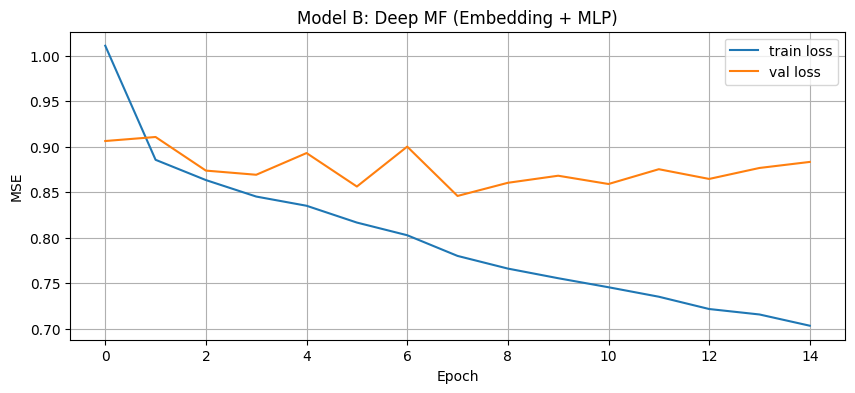

In [ ]:
r_deep = model_deep.fit(
    x=[df_train.userId.values, df_train.movie_idx.values],
    y=df_train.rating.values - mu,
    epochs=15,
    batch_size=128,
    validation_data=(
        [df_test.userId.values, df_test.movie_idx.values],
        df_test.rating.values - mu
    )
)

plt.figure(figsize=(10, 4))
plt.plot(r_deep.history['loss'], label='train loss')
plt.plot(r_deep.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Model B: Deep MF (Embedding + MLP)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from scipy.sparse import lil_matrix

# Q11. 희소 행렬로 User-Item Matrix 구성
A_train = lil_matrix((N, M))
A_test = lil_matrix((N, M))

for row in df_train.itertuples():
    A_train[row.userId, row.movie_idx] = row.rating

for row in df_test.itertuples():
    A_test[row.userId, row.movie_idx] = row.rating

# Dense로 변환 (100K는 크기가 작으므로 가능)
A_train_dense = A_train.toarray()
A_test_dense = A_test.toarray()

# Q12. 마스크 행렬: 평점이 있는 위치는 1, 없는 위치는 0
mask_train = (A_train_dense > 0) * 1
mask_test = (A_test_dense > 0) * 1

# 전체 평균으로 센터링
mu_auto = A_train_dense.sum() / mask_train.sum()
print(f"AutoRec mu: {mu_auto:.4f}")

A_train_centered = A_train_dense - mu_auto * mask_train
A_test_centered = A_test_dense - mu_auto * mask_test

AutoRec mu: 3.5319


In [ ]:
import tensorflow.keras.backend as K_backend

# Q13. 커스텀 손실 함수: 평점이 존재하는 위치만 MSE 계산
def custom_loss(y_true, y_pred):
    # 0이 아닌 위치 마스크
    mask = K_backend.cast(K_backend.not_equal(y_true, 0), dtype='float32')
    diff = y_pred - y_true
    # Q14. 마스크를 적용하여 0인 위치의 오차를 무시
    sqdiff = diff * diff * mask
    sse = K_backend.sum(K_backend.sum(sqdiff))
    n = K_backend.sum(K_backend.sum(mask))
    return sse / n

# Q15. 오토인코더 구조: Input(M) -> Hidden -> Output(M)
i = Input(shape=(M,))                        # 영화 수 = M
x3 = Dropout(0.7)(i)
x3 = Dense(128, activation='tanh')(x3)       # 은닉층 128
x3 = Dense(M, activation=None)(x3)          # 출력층 = M (재구성)

model_autorec = Model(i, x3)
model_autorec.compile(
    loss=custom_loss,
    optimizer=SGD(learning_rate=0.08, momentum=0.9),
    metrics=[custom_loss]
)
model_autorec.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1682)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1682)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       215,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1682)           │       216,978 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 432,402 (1.65 MB)

 Trainable params: 432,402 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Q16. AutoRec 학습 - 입력과 출력이 동일한 User 벡터
r_auto = model_autorec.fit(
    x=A_train_centered,        # 센터링된 훈련 User-Item 벡터
    y=A_train_centered,        # 동일한 벡터 (재구성 목표)
    epochs=20,
    batch_size=128,
    validation_data=(A_train_centered, A_test_centered)  # 훈련 입력 -> 테스트 출력
)


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - custom_loss: 1.2996 - loss: 1.2988 - val_custom_loss: 1.2832 - val_loss: 1.2900
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - custom_loss: 1.3144 - loss: 1.2790 - val_custom_loss: 1.2643 - val_loss: 1.2709
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - custom_loss: 1.2562 - loss: 1.2472 - val_custom_loss: 1.2391 - val_loss: 1.2455
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - custom_loss: 1.2039 - loss: 1.2059 - val_custom_loss: 1.2077 - val_loss: 1.2138
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - custom_loss: 1.1549 - loss: 1.1597 - val_custom_loss: 1.1720 - val_loss: 1.1777
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - custom_loss: 1.1108 - loss: 1.1086 - val_custom_loss: 1.1372 - val_loss: 1.1428
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - custom_loss: 1.0888 - loss: 1.0668 - val_custom_loss: 1.1087 - val_loss: 1.1142
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - custom_loss: 1.0241 - loss: 1.03

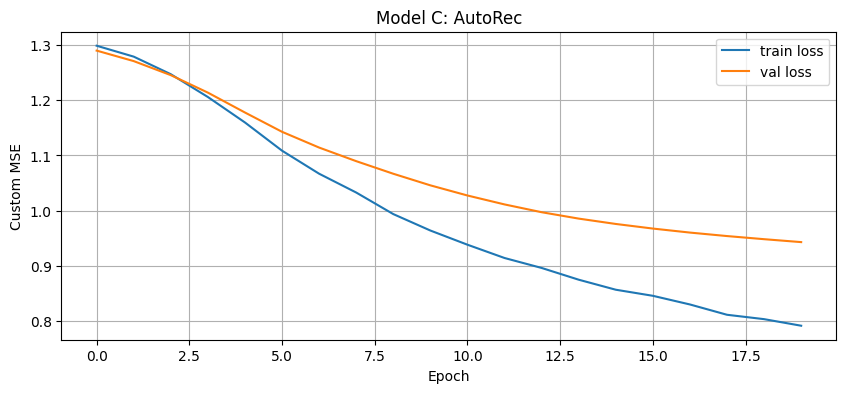

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(r_auto.history['loss'], label='train loss')
plt.plot(r_auto.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Custom MSE')
plt.title('Model C: AutoRec')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from math import sqrt

print("=" * 50)
print("Final Validation MSE Comparison")
print("=" * 50)
print(f"  Embedding MF:  {r_mf.history['val_loss'][-1]:.4f}")
print(f"  Deep MF:       {r_deep.history['val_loss'][-1]:.4f}")
print(f"  AutoRec:       {r_auto.history['val_loss'][-1]:.4f}")
print("=" * 50)

Final Validation MSE Comparison
  Embedding MF:  0.8553
  Deep MF:       0.8834
  AutoRec:       0.9428
